### Loading the Dataset

Total images found: 3999
Valid samples with full annotations: 3999
Sample index: 0
Expression ID: 0 -> Neutral
Valence: -0.176846
Arousal: -0.0776398
Landmarks shape: (68, 2)


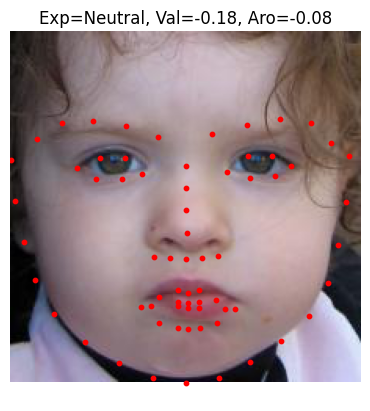

In [1]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# Paths
DATASET_PATH = "Dataset"
IMAGE_PATH = os.path.join(DATASET_PATH, "images")
ANNOT_PATH = os.path.join(DATASET_PATH, "annotations")

# Expression label mapping
expression_map = {
    0: "Neutral",
    1: "Happy",
    2: "Sad",
    3: "Surprise",
    4: "Fear",
    5: "Disgust",
    6: "Anger",
    7: "Contempt"
}

def load_sample(idx):
    img = Image.open(os.path.join(IMAGE_PATH, f"{idx}.jpg"))
    exp = np.load(os.path.join(ANNOT_PATH, f"{idx}_exp.npy"))
    val = np.load(os.path.join(ANNOT_PATH, f"{idx}_val.npy"))
    aro = np.load(os.path.join(ANNOT_PATH, f"{idx}_aro.npy"))
    land = np.load(os.path.join(ANNOT_PATH, f"{idx}_lnd.npy"))

    # Reshape landmarks (136 → 68x2)
    if land.ndim == 1 and land.shape[0] == 136:
        land = land.reshape(-1, 2)

    # Cast to proper types
    exp = int(exp)
    val = float(val)
    aro = float(aro)

    return img, exp, val, aro, land

# Collect valid samples
valid_samples = []
all_files = sorted(os.listdir(IMAGE_PATH), key=lambda x: int(x.split(".")[0]))
for f in all_files:
    idx = int(f.split(".")[0])

    # Check if ALL annotation files exist
    exp_file = os.path.join(ANNOT_PATH, f"{idx}_exp.npy")
    val_file = os.path.join(ANNOT_PATH, f"{idx}_val.npy")
    aro_file = os.path.join(ANNOT_PATH, f"{idx}_aro.npy")
    lnd_file = os.path.join(ANNOT_PATH, f"{idx}_lnd.npy")

    if not (os.path.exists(exp_file) and os.path.exists(val_file) and os.path.exists(aro_file) and os.path.exists(lnd_file)):
        continue  # skip incomplete samples

    # Load val/aro to check if valid
    val = np.load(val_file)
    aro = np.load(aro_file)
    if val == -2 or aro == -2:
        continue  # skip invalid labels

    valid_samples.append(idx)

print("Total images found:", len(all_files))
print("Valid samples with full annotations:", len(valid_samples))

# Pick one valid sample
sample_idx = valid_samples[0]
img, exp, val, aro, land = load_sample(sample_idx)

print("Sample index:", sample_idx)
print("Expression ID:", exp, "->", expression_map[exp])
print("Valence:", val)
print("Arousal:", aro)
print("Landmarks shape:", land.shape)

# Visualize
plt.imshow(img)
plt.scatter(land[:, 0], land[:, 1], c="red", s=10)
plt.title(f"Exp={expression_map[exp]}, Val={val:.2f}, Aro={aro:.2f}")
plt.axis("off")
plt.show()


### CNN model: ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------
# 1. Prepare data arrays
# -----------------------
images = []
expressions = []
valences = []
arousals = []

for idx in valid_samples:
    img, exp, val, aro, land = load_sample(idx)
    img = img.resize((224, 224))   # ensure size
    img = np.array(img) / 255.0    # normalize
    images.append(img)
    expressions.append(exp)
    valences.append(val)
    arousals.append(aro)

images = np.array(images, dtype=np.float32)
expressions = np.array(expressions, dtype=np.int32)
valences = np.array(valences, dtype=np.float32)
arousals = np.array(arousals, dtype=np.float32)

# One-hot encode expressions
num_classes = 8
expressions_oh = tf.keras.utils.to_categorical(expressions, num_classes=num_classes)

print("Images shape:", images.shape)
print("Expressions shape:", expressions_oh.shape)
print("Valences shape:", valences.shape)
print("Arousals shape:", arousals.shape)

# -----------------------
# 2. Train/Val split
# -----------------------
X_train, X_val, y_exp_train, y_exp_val, y_val_train, y_val_val, y_aro_train, y_aro_val = train_test_split(
    images, expressions_oh, valences, arousals, test_size=0.2, random_state=42, stratify=expressions
)

# -----------------------
# 3. Data pipeline
# -----------------------
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, {"expression": y_exp_train, "valence": y_val_train, "arousal": y_aro_train}))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, {"expression": y_exp_val, "valence": y_val_val, "arousal": y_aro_val}))

train_ds = train_ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# -----------------------
# 4. Model (ResNet50 backbone + 3 heads)
# -----------------------
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze backbone initially
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Expression classifier
c = layers.Dense(256, activation="relu")(x)
c = layers.Dropout(0.3)(c)
out_exp = layers.Dense(num_classes, activation="softmax", name="expression")(c)

# Valence regressor
v = layers.Dense(128, activation="relu")(x)
out_val = layers.Dense(1, activation="linear", name="valence")(v)

# Arousal regressor
a = layers.Dense(128, activation="relu")(x)
out_aro = layers.Dense(1, activation="linear", name="arousal")(a)

model = Model(inputs, [out_exp, out_val, out_aro])

# -----------------------
# 5. Compile
# -----------------------
losses = {
    "expression": "categorical_crossentropy",
    "valence": "mse",
    "arousal": "mse"
}
loss_weights = {"expression": 1.0, "valence": 0.5, "arousal": 0.5}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics={"expression": "accuracy"}
)

model.summary()

# -----------------------
# 6. Train
# -----------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("resnet50_baseline.h5", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\riyya\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\riyya\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\riyya\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\riyya\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\riyya\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_3 (GetItem)          │ (None, 224, 224)          │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_4 (GetItem)          │ (None, 224, 224)          │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_5 (GetItem)          │ (None, 224, 224)          │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack_1 (Stack)               │ (None, 224, 224, 3)       │               0 │ get_item_3[0][0],          │
│                               │                           │                 │ get_item_4[0][0],          │
│                               │                           │                 │ get_item_5[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 224, 224, 3)       │               0 │ stack_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ add_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 512)               │       1,049,088 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 512)               │           2,048 │ dense_4[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 512)               │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 256)               │         131,328 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 256)               │               0 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 128)               │          65,664 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 128)               │          65,664 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,903,818 (95.00 MB)

 Trainable params: 1,315,082 (5.02 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - arousal_loss: 0.1898 - expression_accuracy: 0.1882 - expression_loss: 2.0499 - loss: 4.3188 - valence_loss: 0.2484 - val_arousal_loss: 0.1670 - val_expression_accuracy: 0.1988 - val_expression_loss: 2.0022 - val_loss: 4.2065 - val_valence_loss: 0.2371 - learning_rate: 2.0000e-05
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - arousal_loss: 0.1869 - expression_accuracy: 0.1828 - expression_loss: 2.0480 - loss: 4.3147 - valence_loss: 0.2508  

100/100 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - arousal_loss: 0.1869 - expression_accuracy: 0.1828 - expression_loss: 2.0480 - loss: 4.3149 - valence_loss: 0.2508 - val_arousal_loss: 0.1616 - val_expression_accuracy: 0.2200 - val_expression_loss: 1.9928 - val_loss: 4.1810 - val_valence_loss: 0.2292 - learning_rate: 2.0000e-05
Epoch 13/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1546s 15s/step - arousal_loss: 0.1862 - expression_accuracy: 0.1984 - expression_loss: 2.0295 - loss: 4.2759 - valence_loss: 0.2475 - val_arousal_loss: 0.1692 - val_expression_accuracy: 0.2325 - val_expression_loss: 2.0087 - val_loss: 4.2185 - val_valence_loss: 0.2331 - learning_rate: 2.0000e-05
Epoch 14/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2417s 2s/step - arousal_loss: 0.1809 - expression_accuracy: 0.1861 - expression_loss: 2.0539 - loss: 4.3221 - valence_loss: 0.2479 - val_arousal_loss: 0.1690 - val_expression_accuracy: 0.2087 - val_expression_loss: 2.0178 - val_loss: 4.2373 - val_valence_loss: 0.2345 - learning_rate: 2.0000e-05
E

100/100 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - arousal_loss: 0.1851 - expression_accuracy: 0.1987 - expression_loss: 2.0228 - loss: 4.2626 - valence_loss: 0.2487 - val_arousal_loss: 0.1590 - val_expression_accuracy: 0.2250 - val_expression_loss: 1.9906 - val_loss: 4.1749 - val_valence_loss: 0.2284 - learning_rate: 4.0000e-06
Epoch 18/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - arousal_loss: 0.1829 - expression_accuracy: 0.2041 - expression_loss: 2.0194 - loss: 4.2531 - valence_loss: 0.2457  

100/100 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - arousal_loss: 0.1829 - expression_accuracy: 0.2041 - expression_loss: 2.0195 - loss: 4.2532 - valence_loss: 0.2457 - val_arousal_loss: 0.1579 - val_expression_accuracy: 0.2262 - val_expression_loss: 1.9901 - val_loss: 4.1733 - val_valence_loss: 0.2283 - learning_rate: 4.0000e-06
Epoch 19/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - arousal_loss: 0.1815 - expression_accuracy: 0.2057 - expression_loss: 2.0247 - loss: 4.2671 - valence_loss: 0.2541  

100/100 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - arousal_loss: 0.1815 - expression_accuracy: 0.2056 - expression_loss: 2.0248 - loss: 4.2673 - valence_loss: 0.2540 - val_arousal_loss: 0.1586 - val_expression_accuracy: 0.2250 - val_expression_loss: 1.9892 - val_loss: 4.1718 - val_valence_loss: 0.2281 - learning_rate: 4.0000e-06
Epoch 20/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2064s 21s/step - arousal_loss: 0.1805 - expression_accuracy: 0.1862 - expression_loss: 2.0410 - loss: 4.2935 - valence_loss: 0.2426 - val_arousal_loss: 0.1578 - val_expression_accuracy: 0.2300 - val_expression_loss: 1.9917 - val_loss: 4.1768 - val_valence_loss: 0.2289 - learning_rate: 4.0000e-06
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step 

Classification Report (Expressions):
              precision    recall  f1-score   support

     Class 0       0.30      0.12      0.17       100
     Class 1       0.26      0.50      0.34       100
     Class 2       0.14      0.13      0.13       100
     Class 3       0.21      0.15      0.17

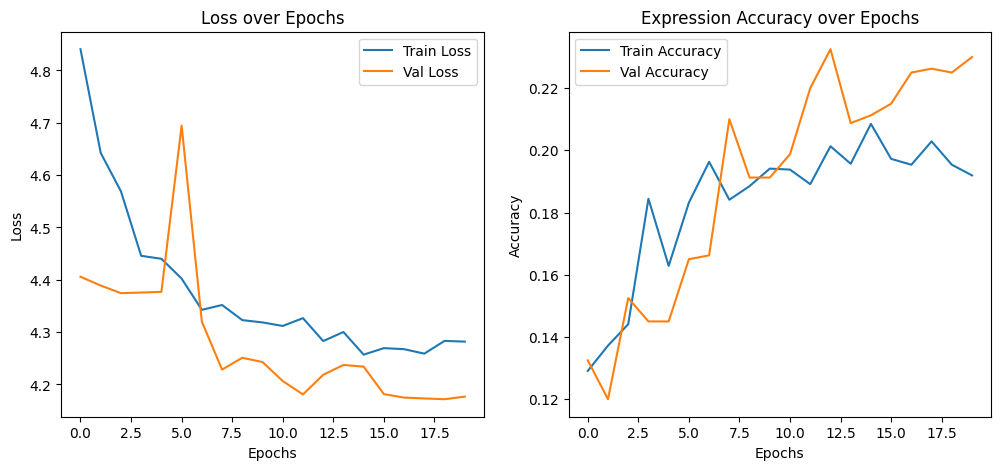

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------
# 1. Prepare data arrays
# -----------------------
images, expressions, valences, arousals = [], [], [], []

for idx in valid_samples:
    img, exp, val, aro, land = load_sample(idx)
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    images.append(img)
    expressions.append(exp)
    valences.append(val)
    arousals.append(aro)

images = np.array(images, dtype=np.float32)
expressions = np.array(expressions, dtype=np.int32)
valences = np.array(valences, dtype=np.float32)
arousals = np.array(arousals, dtype=np.float32)

# One-hot encode expressions
num_classes = 8
expressions_oh = tf.keras.utils.to_categorical(expressions, num_classes=num_classes)

# -----------------------
# 2. Train/Val split
# -----------------------
X_train, X_val, y_exp_train, y_exp_val, y_val_train, y_val_val, y_aro_train, y_aro_val = train_test_split(
    images, expressions_oh, valences, arousals,
    test_size=0.2, random_state=42, stratify=expressions
)

# -----------------------
# 3. Data pipeline + augmentation
# -----------------------
batch_size = 32

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def augment(img, labels):
    return data_augmentation(img), labels

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, {"expression": y_exp_train, "valence": y_val_train, "arousal": y_aro_train})
).map(augment).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, {"expression": y_exp_val, "valence": y_val_val, "arousal": y_aro_val})
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# -----------------------
# 4. Model (ResNet50 backbone + 3 heads)
# -----------------------
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Expression classifier
c = layers.Dense(256, activation="relu")(x)
c = layers.Dropout(0.3)(c)
out_exp = layers.Dense(num_classes, activation="softmax", name="expression")(c)

# Valence regressor
v = layers.Dense(128, activation="relu")(x)
out_val = layers.Dense(1, activation="linear", name="valence")(v)

# Arousal regressor
a = layers.Dense(128, activation="relu")(x)
out_aro = layers.Dense(1, activation="linear", name="arousal")(a)

model = Model(inputs, [out_exp, out_val, out_aro])

# -----------------------
# 5. Compile (Quick Fix: Boost Expression Loss Weight)
# -----------------------
losses = {
    "expression": "categorical_crossentropy",
    "valence": "mse",
    "arousal": "mse"
}
loss_weights = {"expression": 2.0, "valence": 0.5, "arousal": 0.5}  # boost expression

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics={"expression": "accuracy"}
)

model.summary()

# -----------------------
# 6. Training with callbacks
# -----------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("resnet50_baseline.h5", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2),
    # Unfreeze top layers after 10 epochs
    tf.keras.callbacks.LambdaCallback(on_epoch_begin=lambda epoch, logs: 
        setattr(base_model, "trainable", True) if epoch == 10 else None)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# -----------------------
# 7. Evaluation Metrics
# -----------------------
y_pred_exp, y_pred_val, y_pred_aro = model.predict(X_val)
y_true_exp = np.argmax(y_exp_val, axis=1)
y_pred_exp_labels = np.argmax(y_pred_exp, axis=1)

# Classification metrics
print("\nClassification Report (Expressions):")
print(classification_report(y_true_exp, y_pred_exp_labels, target_names=[f"Class {i}" for i in range(num_classes)]))

f1_macro = f1_score(y_true_exp, y_pred_exp_labels, average="macro")
kappa = cohen_kappa_score(y_true_exp, y_pred_exp_labels)
try:
    auc_macro = roc_auc_score(y_exp_val, y_pred_exp, multi_class="ovr")
    auc_pr = average_precision_score(y_exp_val, y_pred_exp, average="macro")
except:
    auc_macro, auc_pr = None, None

# Regression metrics
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred)**2))
def pearson_corr(y_true, y_pred): return np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
def sagr(y_true, y_pred): return np.mean(np.sign(y_true) == np.sign(y_pred))
def ccc(y_true, y_pred):
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "F1 (Macro)", "Cohen’s Kappa", "ROC-AUC", "PR-AUC",
        "Valence RMSE", "Valence Pearson", "Valence SAGR", "Valence CCC",
        "Arousal RMSE", "Arousal Pearson", "Arousal SAGR", "Arousal CCC"
    ],
    "Score": [
        np.mean(y_true_exp == y_pred_exp_labels),
        f1_macro,
        kappa,
        auc_macro,
        auc_pr,
        rmse(y_val_val, y_pred_val),
        pearson_corr(y_val_val, y_pred_val),
        sagr(y_val_val, y_pred_val),
        ccc(y_val_val, y_pred_val),
        rmse(y_aro_val, y_pred_aro),
        pearson_corr(y_aro_val, y_pred_aro),
        sagr(y_aro_val, y_pred_aro),
        ccc(y_aro_val, y_pred_aro)
    ]
})
print("\nEvaluation Table:\n", metrics_table)

# -----------------------
# 8. Training Graphs
# -----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["expression_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_expression_accuracy"], label="Val Accuracy")
plt.title("Expression Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [ ]:
### Custom CNN Model

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=8):
    inputs = layers.Input(shape=input_shape)

    # Convolutional Block 1
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convolutional Block 2
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convolutional Block 3
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convolutional Block 4 (optional, deeper feature extraction)
    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flatten + Fully Connected
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Multi-task heads
    expression_output = layers.Dense(num_classes, activation="softmax", name="expression")(x)
    valence_output = layers.Dense(1, activation="linear", name="valence")(x)
    arousal_output = layers.Dense(1, activation="linear", name="arousal")(x)

    model = models.Model(inputs=inputs, outputs=[expression_output, valence_output, arousal_output])
    return model


# Build model
custom_cnn = build_custom_cnn()

# Compile with multitask loss
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss={
        "expression": "sparse_categorical_crossentropy",
        "valence": "mse",
        "arousal": "mse"
    },
    metrics={
        "expression": "accuracy",
        "valence": "mae",
        "arousal": "mae"
    }
)

custom_cnn.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 224, 224, 32)      │             896 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 112, 112, 32)      │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 112, 112, 64)      │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 56, 56, 64)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 128)       │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 28, 28, 128)       │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 28, 28, 256)       │         295,168 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 14, 14, 256)       │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 50176)             │               0 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 256)               │      12,845,312 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 256)               │               0 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expression (Dense)            │ (None, 8)                 │           2,056 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ valence (Dense)               │ (None, 1)                 │             257 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ arousal (Dense)               │ (None, 1)                 │             257 │ dropout_4[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 13,236,298 (50.49 MB)

 Trainable params: 13,236,298 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------
# 1. Prepare data arrays
# -----------------------
images, expressions, valences, arousals = [], [], [], []

for idx in valid_samples:
    img, exp, val, aro, land = load_sample(idx)
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    images.append(img)
    expressions.append(exp)
    valences.append(val)
    arousals.append(aro)

images = np.array(images, dtype=np.float32)
expressions = np.array(expressions, dtype=np.int32)
valences = np.array(valences, dtype=np.float32)
arousals = np.array(arousals, dtype=np.float32)

# One-hot encode expressions
num_classes = 8
expressions_oh = tf.keras.utils.to_categorical(expressions, num_classes=num_classes)

# -----------------------
# 2. Train/Val split
# -----------------------
X_train, X_val, y_exp_train, y_exp_val, y_val_train, y_val_val, y_aro_train, y_aro_val = train_test_split(
    images, expressions_oh, valences, arousals,
    test_size=0.2, random_state=42, stratify=expressions
)

# -----------------------
# 3. Data pipeline + augmentation
# -----------------------
batch_size = 32

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def augment(img, labels):
    return data_augmentation(img), labels

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, {"expression": y_exp_train, "valence": y_val_train, "arousal": y_aro_train})
).map(augment).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, {"expression": y_exp_val, "valence": y_val_val, "arousal": y_aro_val})
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# -----------------------
# 4. Model (MobileNetV2 backbone + 3 heads)
# -----------------------
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Expression classifier
c = layers.Dense(256, activation="relu")(x)
c = layers.Dropout(0.3)(c)
out_exp = layers.Dense(num_classes, activation="softmax", name="expression")(c)

# Valence regressor
v = layers.Dense(128, activation="relu")(x)
out_val = layers.Dense(1, activation="linear", name="valence")(v)

# Arousal regressor
a = layers.Dense(128, activation="relu")(x)
out_aro = layers.Dense(1, activation="linear", name="arousal")(a)

model = Model(inputs, [out_exp, out_val, out_aro])

# -----------------------
# 5. Compile
# -----------------------
losses = {
    "expression": "categorical_crossentropy",
    "valence": "mse",
    "arousal": "mse"
}
loss_weights = {"expression": 2.0, "valence": 0.5, "arousal": 0.5}  # boost expression

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics={"expression": "accuracy"}
)

model.summary()

# -----------------------
# 6. Training with callbacks
# -----------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("mobilenetv2_baseline.h5", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2),
    # Unfreeze top layers after 10 epochs
    tf.keras.callbacks.LambdaCallback(on_epoch_begin=lambda epoch, logs: 
        setattr(base_model, "trainable", True) if epoch == 10 else None)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# -----------------------
# 7. Evaluation Metrics
# -----------------------
y_pred_exp, y_pred_val, y_pred_aro = model.predict(X_val)
y_true_exp = np.argmax(y_exp_val, axis=1)
y_pred_exp_labels = np.argmax(y_pred_exp, axis=1)

# Classification metrics
print("\nClassification Report (Expressions):")
print(classification_report(y_true_exp, y_pred_exp_labels, target_names=[f"Class {i}" for i in range(num_classes)]))

f1_macro = f1_score(y_true_exp, y_pred_exp_labels, average="macro")
kappa = cohen_kappa_score(y_true_exp, y_pred_exp_labels)
try:
    auc_macro = roc_auc_score(y_exp_val, y_pred_exp, multi_class="ovr")
    auc_pr = average_precision_score(y_exp_val, y_pred_exp, average="macro")
except:
    auc_macro, auc_pr = None, None

# Regression metrics
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred)**2))
def pearson_corr(y_true, y_pred): return np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
def sagr(y_true, y_pred): return np.mean(np.sign(y_true) == np.sign(y_pred))
def ccc(y_true, y_pred):
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "F1 (Macro)", "Cohen’s Kappa", "ROC-AUC", "PR-AUC",
        "Valence RMSE", "Valence Pearson", "Valence SAGR", "Valence CCC",
        "Arousal RMSE", "Arousal Pearson", "Arousal SAGR", "Arousal CCC"
    ],
    "Score": [
        np.mean(y_true_exp == y_pred_exp_labels),
        f1_macro,
        kappa,
        auc_macro,
        auc_pr,
        rmse(y_val_val, y_pred_val),
        pearson_corr(y_val_val, y_pred_val),
        sagr(y_val_val, y_pred_val),
        ccc(y_val_val, y_pred_val),
        rmse(y_aro_val, y_pred_aro),
        pearson_corr(y_aro_val, y_pred_aro),
        sagr(y_aro_val, y_pred_aro),
        ccc(y_aro_val, y_pred_aro)
    ]
})
print("\nEvaluation Table:\n", metrics_table)

# -----------------------
# 8. Training Graphs
# -----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["expression_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_expression_accuracy"], label="Val Accuracy")
plt.title("Expression Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)   │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ true_divide (TrueDivide)      │ (None, 224, 224, 3)       │               0 │ input_layer_11[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ subtract (Subtract)           │ (None, 224, 224, 3)       │               0 │ true_divide[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)        │       2,257,984 │ subtract[0][0]             │
│ (Functional)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_3    │ (None, 1280)              │               0 │ mobilenetv2_1.00_224[0][0] │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 512)               │         655,872 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 512)               │           2,048 │ dense_13[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 512)               │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 256)               │         131,328 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 256)               │               0 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_15 (Dense)              │ (None, 128)               │          65,664 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 128)               │          65,664 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expression (Dense)            │ (None, 8)                 │           2,056 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ valence (Dense)               │ (None, 1)                 │             129 │ dense_15[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ arousal (Dense)               │ (None, 1)                 │             129 │ dense_16[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,180,874 (12.13 MB)

 Trainable params: 921,866 (3.52 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - arousal_loss: 0.2830 - expression_accuracy: 0.1273 - expression_loss: 2.1768 - loss: 4.6838 - valence_loss: 0.3776  

100/100 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - arousal_loss: 0.2827 - expression_accuracy: 0.1272 - expression_loss: 2.1766 - loss: 4.6833 - valence_loss: 0.3774 - val_arousal_loss: 0.3203 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0948 - val_loss: 4.5534 - val_valence_loss: 0.4074 - learning_rate: 1.0000e-04
Epoch 2/20
